First we need to get a MyToken to identify ourselves using OIDC (OpenID Connect) protocol to the drift-watch API.
Navigate to [mytok.eu](https://mytok.eu), log in using EGI Check-in and create a new MyToken.
Create an environment variable **DRIFT_MONITOR_MYTOKEN** using the MyToken value.

Additionally you might need to set **DRIFT_MONITOR_URL** in order to use a valid drift-watch API endpoint. By the time this example was written, the used value is `https://drift-watch.dev.ai4eosc.eu`.

> We recommend that can set up "Audiences" to the drift-watch server or to use so that token can be used only for the drift-watch API.


![Create MyToken](images/create-mytoken.png)


Import environment dependencies and load '.env' variables to use the drift-watch my-token and custom urls.


In [1]:
from dotenv import load_dotenv

_ = load_dotenv()

Import all the necessary libraries.


In [2]:
import pickle

import torchvision.transforms as transforms
import drift_monitor as dw  # drift-watch
import torch
from PIL import Image

Register to the service in case you did not do it before and set/create an experiment to use the drift-watch service to monitor the drift in the data.


In [3]:
dw.register(accept_terms=True)

In [4]:
description = "This is an experiment to track camera status on OBSEA project."
try:
    dw.new_experiment("obsea-camera", description, public=True)
except ValueError:
    print("Experiment already exists. Skipping creation.")

Experiment already exists. Skipping creation.


Define your detector method. In this case we load the trained detector and define a function to test an input image. The return value is a tuple where the first element is the drift status and the second element are the test statistics.


In [5]:
with open("models/autoencoder.pt", "rb") as f:
    autoencoder = torch.load(f, weights_only=False).to("cpu")

In [6]:
with open("models/ddetector.pkl", "rb") as f:
    detector = pickle.load(f)

In [7]:
def test_drift(images, alpha=0.08) -> tuple[bool, dict]:
    batch_images = torch.stack([transforms.ToTensor()(x) for x in images])
    encodings = autoencoder.encoder(batch_images)
    _, callback_logs = detector.compare(X=encodings.detach().numpy())
    p_value = callback_logs["PermutationTestDistanceBased"]["p_value"]
    return p_value <= alpha, callback_logs

Now we load an example image from the example dataset.


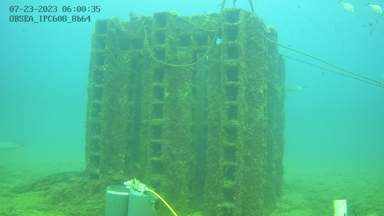

In [8]:
images = [
    Image.open(f"notebooks/images/{x}.jpg").convert("RGB").resize((384, 216))
    for x in [
        "20230723-060036-IPC608_8B64_165",
        "20230723-090037-IPC608_8B64_165",
    ]
]
images[0]

Now open a DriftMonitor context and call the detectors. The DriftMonitor will store the results in a dictionary with the detector names as keys and the tuple (detection, features) as values.


In [9]:
tags = ["obsea", "ai4os", "data-drift", "DDM", "example_docs"]
with dw.DriftMonitor("obsea-camera", "v3.1", tags) as monitor:
    detected, detection_parameters = test_drift(images)
    monitor(detected, detection_parameters)
print("Drift detected:", detected)
detection_parameters

Drift detected: True


{'PermutationTestDistanceBased': {'observed_statistic': np.float64(0.04118168564027733),
  'permuted_statistics': array([ 2.20130302e-02,  1.59286214e-02, -1.10879615e-01,  2.92455030e-02,
          9.90554710e-03, -1.10349910e-01,  3.39229486e-02,  1.36357153e-02,
          3.81828230e-02,  2.25357838e-02, -1.44025732e-01,  3.23799188e-02,
          2.19335387e-02, -1.13297535e-01, -7.00474783e-02,  3.21251862e-02,
          3.23799188e-02, -1.10869242e-01,  2.14024525e-03,  4.20576548e-02,
          4.01174065e-02,  4.96926906e-02, -1.13297535e-01,  3.15756606e-02,
          3.87326694e-02,  8.09251126e-03,  3.81828230e-02,  1.64628735e-02,
          2.92455030e-02,  2.06060670e-02,  8.53012636e-01,  3.45742024e-02,
          3.62683797e-02,  2.06060670e-02, -1.22164393e-01,  2.14024525e-03,
         -1.18471848e-01,  1.02630199e-02,  3.35099233e-02,  2.06060670e-02,
         -1.37349482e-01,  4.01174065e-02,  3.23799188e-02, -1.12279627e-01,
          2.06060670e-02, -7.08752005e-02

When the context is closed, the DriftMonitor will send the results to the API with status "Completed". If and exception occurs, the DriftMonitor will catch the exception, send the results with status "Failed" and re-raise the exception.
